Custom CNN model

Loading the data

In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

Setting the path

In [29]:

TRAIN_DIR = "/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/"
VAL_DIR = "/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/"
TEST_DIR = "/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/"

setting the model parameters

In [30]:
# Model parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

# MLflow setup
MLFLOW_EXPERIMENT_NAME = "Chest_XRay_Pneumonia_Classification"

# logging.info("Configuration loaded.")

In [31]:
import os
import tensorflow as tf

# --- Check Training Set ---
num_normal_train = len(os.listdir(os.path.join(TRAIN_DIR, 'NORMAL')))
num_pneumonia_train = len(os.listdir(os.path.join(TRAIN_DIR, 'PNEUMONIA')))
print("Training Set Image Counts:")
print(f"  - NORMAL: {num_normal_train}")
print(f"  - PNEUMONIA: {num_pneumonia_train}")

# --- Check Validation Set ---
num_normal_val = len(os.listdir(os.path.join(VAL_DIR, 'NORMAL')))
num_pneumonia_val = len(os.listdir(os.path.join(VAL_DIR, 'PNEUMONIA')))
print("\nValidation Set Image Counts:")
print(f"  - NORMAL: {num_normal_val}")
print(f"  - PNEUMONIA: {num_pneumonia_val}")

# --- Check Test Set ---
num_normal_test = len(os.listdir(os.path.join(TEST_DIR, 'NORMAL')))
num_pneumonia_test = len(os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA')))
print("\nTest Set Image Counts:")
print(f"  - NORMAL: {num_normal_test}")
print(f"  - PNEUMONIA: {num_pneumonia_test}")

Training Set Image Counts:
  - NORMAL: 1342
  - PNEUMONIA: 3876

Validation Set Image Counts:
  - NORMAL: 9
  - PNEUMONIA: 9

Test Set Image Counts:
  - NORMAL: 234
  - PNEUMONIA: 390


In [32]:

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = validation_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [33]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Get a summary of the model
model.summary()
        


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

Class Weights to handle imbalance: {0: 1.9448173005219984, 1: 0.6730322580645162}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 988ms/step - accuracy: 0.4945 - loss: 0.7373 - val_accuracy: 0.7500 - val_loss: 0.6207
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 979ms/step - accuracy: 0.8243 - loss: 0.3900 - val_accuracy: 0.8125 - val_loss: 0.5720
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 977ms/step - accuracy: 0.8635 - loss: 0.3219 - val_accuracy: 0.8125 - val_loss: 0.3901
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 980ms/step - accuracy: 0.8790 - loss: 0.2832 - val_accuracy: 0.8750 - val_loss: 0.3544
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 978ms/step - accuracy: 0.8799 - loss: 0.2785 - val_accuracy: 0.7500 - val_loss: 0.3675
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 980ms/step - accuracy: 0.8883 - loss: 0.2491 - val_accuracy: 0.8125 - val_loss: 0.4097
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 981ms/step - accuracy: 0.8983 - loss: 0.2450 - val_accuracy: 0.7500 - val_loss: 0.5200
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 980ms/step - accuracy: 0.8974 -

NameError: name 'plt' is not defined

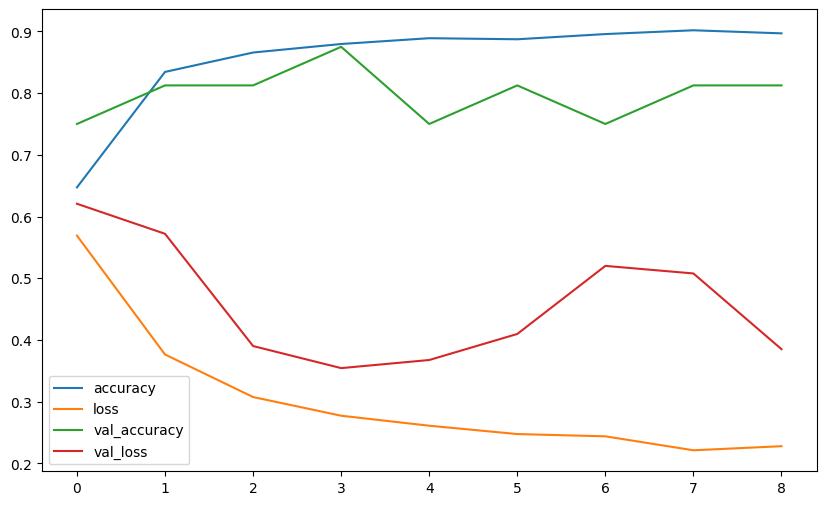

In [34]:
from sklearn.utils import class_weight
import numpy as np
# Calculate class weights to handle the imbalanced training data
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class Weights to handle imbalance: {class_weight_dict}")

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

# Set up Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=5, 
    restore_best_weights=True
)

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

# Plot training history
pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("Model Training History")
plt.show()

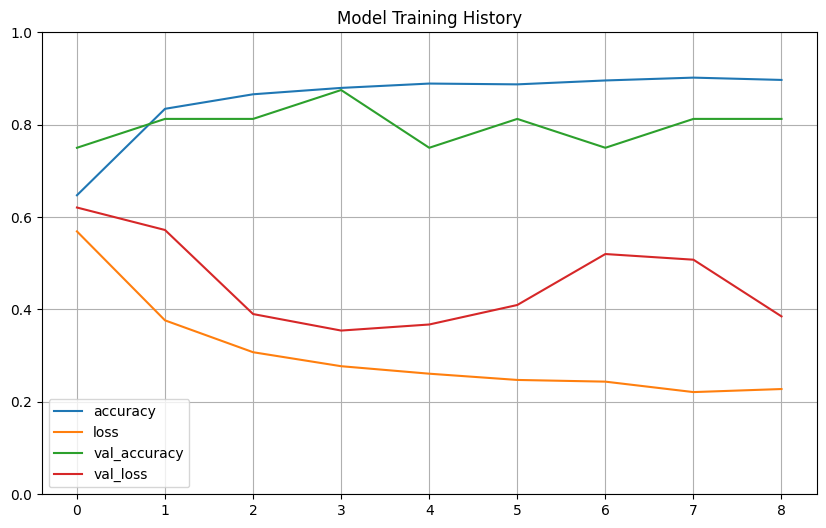

In [36]:
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("Model Training History")
plt.show()

Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 365ms/step


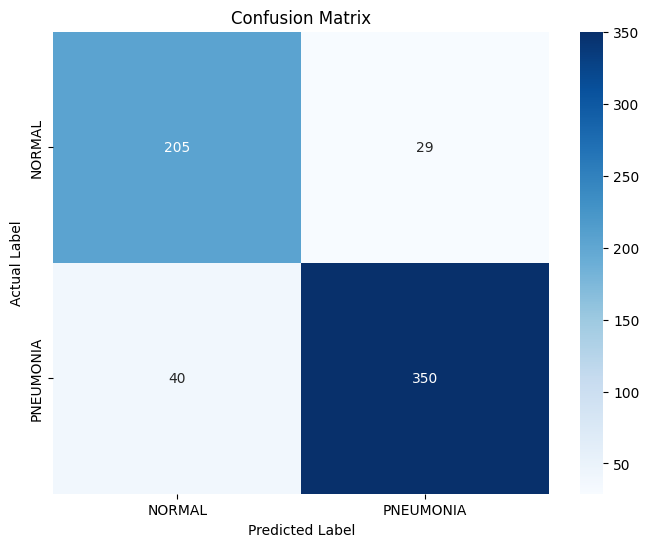


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.84      0.88      0.86       234
   PNEUMONIA       0.92      0.90      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.89      0.88       624
weighted avg       0.89      0.89      0.89       624



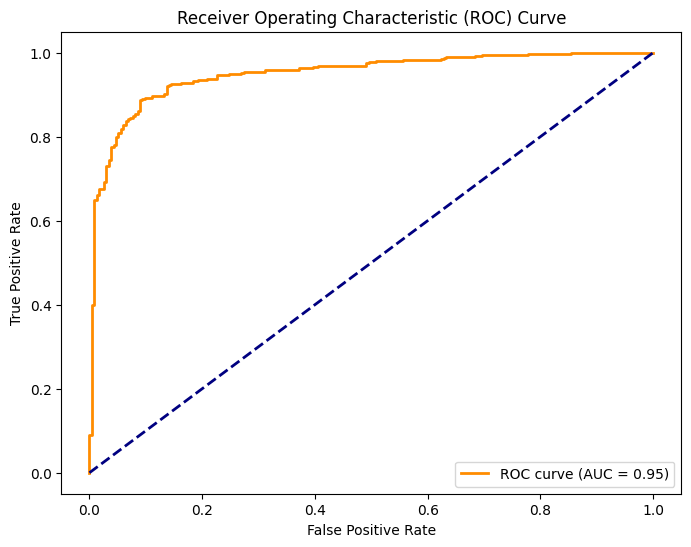

In [41]:
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,auc
import seaborn as sns
# Create a test generator (important: shuffle=False)
test_generator = validation_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Get predictions and true labels
probabilities = model.predict(test_generator)
predictions = (probabilities > 0.5).astype(int).flatten()
true_labels = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- Confusion Matrix ---
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=class_labels))

# --- ROC Curve and AUC Score ---
fpr, tpr, _ = roc_curve(true_labels, probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Based on above two reports CNN performed better

Resnet 50

In [47]:
import os
import sys
import mlflow
import mlflow.tensorflow
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

In [49]:
mlflow.set_tracking_uri("file:/kaggle/working/mlruns")

In [55]:
# --- Define all constants and paths here ---

# IMPORTANT: Update this base path to match your Kaggle dataset's directory
DATA_BASE_PATH = '/kaggle/input/chest-xray-pneumonia/chest_xray/'

TRAIN_DIR = os.path.join(DATA_BASE_PATH, 'train')
VAL_DIR = os.path.join(DATA_BASE_PATH, 'val')
TEST_DIR = os.path.join(DATA_BASE_PATH, 'test')

# Model parameters
# ResNet50 is typically trained on larger images
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32
EPOCHS = 5 # Transfer learning often requires fewer epochs
LEARNING_RATE = 0.0001 # Use a smaller learning rate for fine-tuning

In [56]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = validation_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [57]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load the pre-trained ResNet50 model, excluding its top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add our custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# This is our final model
model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_7[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [58]:
with mlflow.start_run(run_name="ResNet50_with_Class_Weights") as run:
    print(f"Starting MLflow Run: {run.info.run_name}")
    
    # --- Log Hyperparameters ---
    mlflow.log_param("model_architecture", "ResNet50")
    mlflow.log_param("image_size", IMG_SIZE[0])
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("balancing_strategy", "class_weight")
    
    # --- NEW: Calculate Class Weights to handle imbalance ---
    class_weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(train_generator.classes),
        y=train_generator.classes
    )
    class_weight_dict = dict(enumerate(class_weights))
    print(f"Class weights used for training: {class_weight_dict}")
    mlflow.log_param("class_weights", class_weight_dict)

    # --- Compile and Train ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=validation_generator,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)],
        class_weight=class_weight_dict  # Apply the class weights here
    )
    
    # --- Log Final Metrics ---
    mlflow.log_metric("final_val_accuracy", max(history.history['val_accuracy']))
    
    # --- Log Training History Plot ---
    pd.DataFrame(history.history).plot(figsize=(10, 6))
    plt.grid(True)
    history_plot_path = "training_history_resnet_balanced.png"
    plt.savefig(history_plot_path)
    mlflow.log_artifact(history_plot_path, "plots")
    plt.close()

    # --- Log the Model ---
    mlflow.tensorflow.log_model(model, "model")
    
# Save the run ID for the evaluation step
run_id = run.info.run_id

Starting MLflow Run: ResNet50_with_Class_Weights
Class weights used for training: {0: 1.9448173005219984, 1: 0.6730322580645162}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 430s 3s/step - accuracy: 0.5452 - loss: 0.7240 - val_accuracy: 0.7500 - val_loss: 0.6567
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.5920 - loss: 0.6623 - val_accuracy: 0.7500 - val_loss: 0.6345
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 443s 3s/step - accuracy: 0.6518 - loss: 0.6370 - val_accuracy: 0.7500 - val_loss: 0.6172
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.7183 - loss: 0.5973 - val_accuracy: 0.6250 - val_loss: 0.6112


2025/09/02 07:57:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 07:57:06 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/09/02 07:57:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step


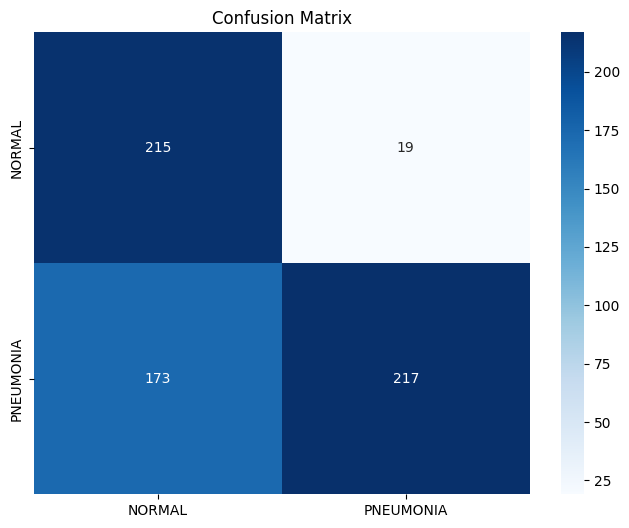

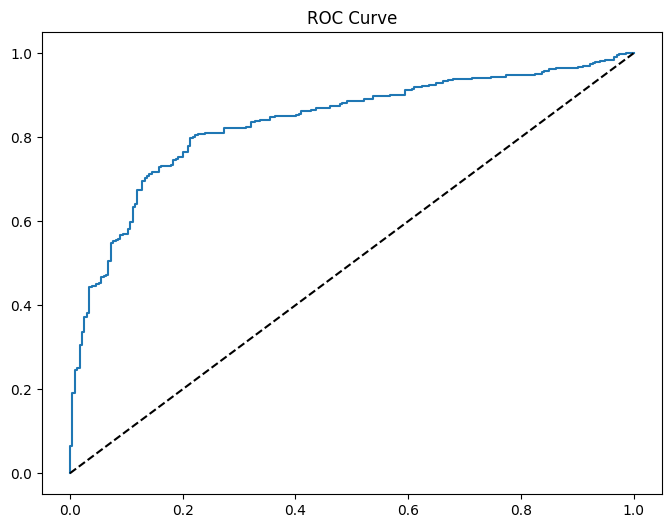

In [59]:
with mlflow.start_run(run_id=run_id):
    # --- Get Predictions ---
    test_generator = validation_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    
    probabilities = model.predict(test_generator)
    predictions = (probabilities > 0.5).astype(int).flatten()
    true_labels = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())
    
    # --- Log Classification Report and Confusion Matrix ---
    report = classification_report(true_labels, predictions, target_names=class_labels, output_dict=True)
    mlflow.log_metric("test_accuracy", report['accuracy'])
    mlflow.log_metric("test_recall_pneumonia", report['PNEUMONIA']['recall'])
    mlflow.log_metric("test_precision_pneumonia", report['PNEUMONIA']['precision'])
    
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix')
    cm_path = "confusion_matrix_resnet_balanced.png"
    plt.savefig(cm_path)
    mlflow.log_artifact(cm_path, "plots")
    plt.show()

    # --- Log ROC Curve ---
    fpr, tpr, _ = roc_curve(true_labels, probabilities)
    roc_auc = auc(fpr, tpr)
    mlflow.log_metric("test_auc", roc_auc)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curve')
    roc_path = "roc_curve_resnet_balanced.png"
    plt.savefig(roc_path)
    mlflow.log_artifact(roc_path, "plots")
    plt.show()

In [62]:
report = classification_report(true_labels, predictions, target_names=class_labels, output_dict=True)
report

{'NORMAL': {'precision': 0.5541237113402062,
  'recall': 0.9188034188034188,
  'f1-score': 0.6913183279742764,
  'support': 234},
 'PNEUMONIA': {'precision': 0.9194915254237288,
  'recall': 0.5564102564102564,
  'f1-score': 0.6932907348242812,
  'support': 390},
 'accuracy': 0.6923076923076923,
 'macro avg': {'precision': 0.7368076183819675,
  'recall': 0.7376068376068377,
  'f1-score': 0.6923045313992788,
  'support': 624},
 'weighted avg': {'precision': 0.7824785951424078,
  'recall': 0.6923076923076923,
  'f1-score': 0.6925510822555294,
  'support': 624}}